In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [17]:
X_train = pd.read_csv('X_train_transformed.csv')
X_test = pd.read_csv('X_test_transformed.csv')

In [19]:
X_train.head()

,num__Age,num__Overall_Rating,num__Future Potential,num__Total_Stats Score,cat_onehot__Continent_Africa,cat_onehot__Continent_Asia,cat_onehot__Continent_Europe,cat_onehot__Continent_North America,cat_onehot__Continent_Oceania,cat_onehot__Continent_South America,...,cat_onehot__Position_LM,cat_onehot__Position_LW,cat_onehot__Position_LWB,cat_onehot__Position_RB,cat_onehot__Position_RM,cat_onehot__Position_RW,cat_onehot__Position_RWB,cat_onehot__Position_ST,cat_onehot__Position_SW,cat_ordinal__Team_Tier
0,-0.428805,0.225650,0.518370,0.650500,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,0.211331,-0.030097,-0.402967,0.700079,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.855562,-0.925212,-0.402967,-0.603150,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.855562,-1.053086,0.211258,-2.455294,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.424709,-0.157971,-1.170747,-0.086108,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
X_train.shape

(15733, 27)

In [21]:
X_train.drop(columns=['num__Overall_Rating'], inplace=True)
X_test.drop(columns=['num__Overall_Rating'], inplace=True) 

In [22]:
y_train_logis = pd.read_csv('y_train_clf.csv').squeeze()
y_test_logis = pd.read_csv('y_test_clf.csv').squeeze()

In [28]:
y_train_logis.value_counts()

Performance_Tier
Mid      7318
Low      5134
High     2863
Elite     418
Name: count, dtype: int64

In [29]:
y_test_logis.value_counts()

Performance_Tier
Mid      1830
Low      1283
High      716
Elite     105
Name: count, dtype: int64

# Training the Model

In [50]:
logistic_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logistic_model.fit(X_train, y_train_logis)  

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [51]:
y_pred_logis = logistic_model.predict(X_test)

# Model Evaluation

In [52]:
accuracy = accuracy_score(y_test_logis, y_pred_logis)
precision = precision_score(y_test_logis, y_pred_logis, average='weighted')
recall = recall_score(y_test_logis, y_pred_logis, average='weighted')    
f1 = f1_score(y_test_logis, y_pred_logis, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.8597
Precision: 0.8648
Recall:    0.8597
F1-Score:  0.8600


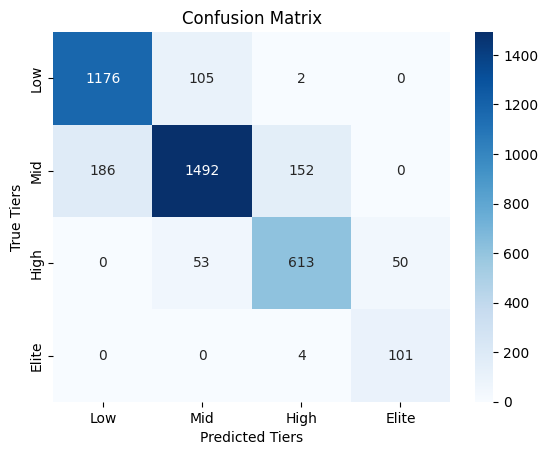

In [53]:
# Confusion Matrix
labels = ['Low', 'Mid', 'High', 'Elite']

cm = confusion_matrix(y_test_logis, y_pred_logis, labels=labels)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted Tiers')
plt.ylabel('True Tiers')
plt.title('Confusion Matrix')

plt.show()

In [54]:
print("Classification Report:") 
print(classification_report(y_test_logis, y_pred_logis, target_names=['low', 'Medium', 'High', 'Elite']))

Classification Report:
              precision    recall  f1-score   support

         low       0.67      0.96      0.79       105
      Medium       0.80      0.86      0.82       716
        High       0.86      0.92      0.89      1283
       Elite       0.90      0.82      0.86      1830

    accuracy                           0.86      3934
   macro avg       0.81      0.89      0.84      3934
weighted avg       0.86      0.86      0.86      3934



## Testing Regularization 

In [38]:
C_values = np.logspace(-3, 3, 7)  # 10^-3 to 10^3

### L2 Regularization

In [39]:
# Store results
train_acc_l2 = []
test_acc_l2 = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty='l2',
        solver='lbfgs',
        max_iter=1000
    )
    
    model.fit(X_train, y_train_logis)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc_l2.append(accuracy_score(y_train_logis, y_train_pred))
    test_acc_l2.append(accuracy_score(y_test_logis, y_test_pred))

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

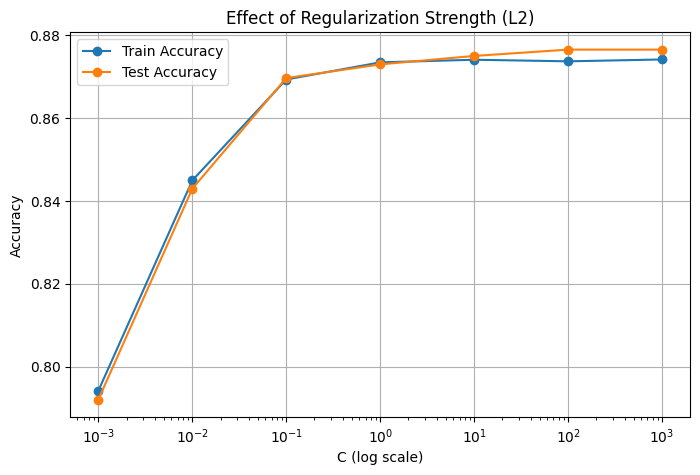

In [40]:
plt.figure(figsize=(8,5))

plt.plot(C_values, train_acc_l2, marker='o', label='Train Accuracy')
plt.plot(C_values, test_acc_l2, marker='o', label='Test Accuracy')

plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization Strength (L2)")
plt.legend()
plt.grid()
plt.show()

In [41]:
# find the best C value based on test accuracy
best_index_l2 = np.argmax(test_acc_l2)
best_C = C_values[best_index_l2]

print("Best C:", best_C)
print("Best Test Accuracy:", test_acc_l2[best_index_l2])

Best C: 100.0
Best Test Accuracy: 0.8764616166751398


### L1 Regularization

In [42]:
train_acc_l1 = []
test_acc_l1 = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty='l1',
        solver='saga',
        max_iter=1000
    )
    
    model.fit(X_train, y_train_logis)
    
    train_acc_l1.append(model.score(X_train, y_train_logis))
    test_acc_l1.append(model.score(X_test, y_test_logis))

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2

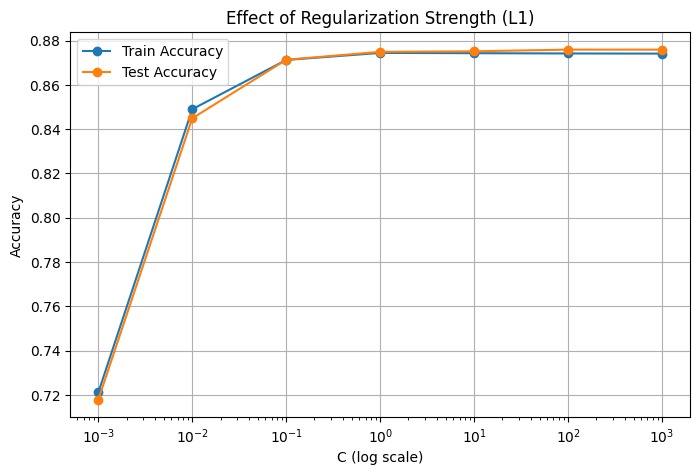

In [43]:
plt.figure(figsize=(8,5))

plt.plot(C_values, train_acc_l1, marker='o', label='Train Accuracy')
plt.plot(C_values, test_acc_l1, marker='o', label='Test Accuracy')

plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization Strength (L1)")
plt.legend()
plt.grid()
plt.show()

In [44]:
# find the best C value based on test accuracy
best_index_l1 = np.argmax(test_acc_l1)
best_C = C_values[best_index_l1]

print("Best C:", best_C)
print("Best Test Accuracy:", test_acc_l1[best_index_l1])

Best C: 100.0
Best Test Accuracy: 0.8759532282663955


In [45]:
# Check number of selected features for L1 regularization
model_l1 = LogisticRegression(C=100, penalty='l1', solver='saga', max_iter=1000)
model_l1.fit(X_train, y_train_logis)

print("L1 non-zero coefficients:", sum(model_l1.coef_[0] != 0))

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1 non-zero coefficients: 26


#### L1 Vs L2 Regularization 
Both L1 and L2 regularization achieved identical performance ~ `0.8765` at optimal C = 100, indicating that the dataset is relatively well-conditioned and does not contain many redundant or irrelevant features. As a result, feature sparsity introduced by L1 does not significantly improve model generalization compared to L2 regularization.